Notebook réalisé par Anthony Sureau

## Imports

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
import glob
import gc
from google.colab import drive
from google.colab import files

import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.model_selection import train_test_split
from sklearn.manifold import TSNE
import matplotlib.cm as cm
from tensorflow.keras import regularizers
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping
import matplotlib.colors as mcolors
from scipy.stats import spearmanr


print(f"TensorFlow {tf.__version__}")

TensorFlow 2.20.0


## Chargement des données

In [ ]:
drive.mount('/content/drive')

dossier = "/content/drive/MyDrive/redshift"
os.chdir(dossier)

# Lister tous les fichiers .npz du dossier
npz_files = glob.glob("*.npz")

# Filtrer uniquement les fichiers contenant "COSMOS"
cosmos_files = [f for f in npz_files if "COSMOS" in f]

# Charger chaque fichier dans un dictionnaire séparé
cosmos_data = {}
for fichier in cosmos_files:
    try:
        cosmos_data[fichier] = np.load(fichier, allow_pickle=True)
        print(f"Chargé : {fichier}")
    except Exception as e:
        print(f"Erreur lors du chargement de {fichier} : {e}")

# Afficher les clés et les shapes de chaque fichier séparément
for nom, data in cosmos_data.items():
    print(f"\n=== {nom} ===")
    for key in data.keys():
        print(f"  - {key} : {data[key].shape}")


# Séparer les fichiers COSMOS en deux groupes : spec et phot
spec_files = [f for f in cosmos_files if "spec" in f.lower()]
phot_files = [f for f in cosmos_files if "phot" in f.lower()]

print("Fichiers SPEC:", spec_files)
print("Fichiers PHOT:", phot_files)

# Charger les données spec
spec_data = np.load(spec_files[0], allow_pickle=True)

# Charger les données phot
phot_data = np.load(phot_files[0], allow_pickle=True)

# Voir ce qu'il y a dans chacun
print("\n=== SPEC ===")
for key in spec_data.keys():
    print(f"  - {key} : {spec_data[key].shape}")

print("\n=== PHOT ===")
for key in phot_data.keys():
    print(f"  - {key} : {phot_data[key].shape}")


# Extraire ce dont tu as besoin (adapte les noms des clés selon ce que tu vois)
spec_info = spec_data["info"]
phot_info = phot_data["info"]



# Convertir en DataFrame pandas pour faciliter la manipulation
spec_df = pd.DataFrame(spec_info)
phot_df = pd.DataFrame(phot_info)

# Renommer les colonnes cibles
spec_df = spec_df.rename(columns={"ZSPEC": "redshift"})
phot_df = phot_df.rename(columns={"ZPHOT": "redshift"})

# Vérifier
print("Colonnes SPEC:", spec_df.columns.tolist())
print("Colonnes PHOT:", phot_df.columns.tolist())

# Vérifier la colonne z dans chacun
print("\nSpec z:", spec_df["redshift"].head())
print("Phot z:", phot_df["redshift"].head())



# Garder uniquement les magnitudes
magnitudes = ['u', 'g', 'r', 'i', 'z', 'y','EBV']

spec_mag = spec_df[magnitudes + ['redshift']].copy()
phot_mag = phot_df[magnitudes + ['redshift']].copy()

# Créer les couleurs (différences entre magnitudes voisines)
for df in [spec_mag, phot_mag]:
    df['u_g'] = df['u'] - df['g']
    df['g_r'] = df['g'] - df['r']
    df['r_i'] = df['r'] - df['i']
    df['i_z'] = df['i'] - df['z']
    df['z_y'] = df['z'] - df['y']

# Vérifier
print("Colonnes SPEC:", spec_mag.columns.tolist())
print(spec_mag.head())

print("\nColonnes PHOT:", phot_mag.columns.tolist())
print(phot_mag.head())


# Filtrer les données : garder uniquement redshift <= 1
#spec_mag = spec_mag[spec_mag['redshift'] <= 1].copy()
# phot_mag = phot_mag[phot_mag['redshift'] <= 1].copy()

print(f"SPEC après filtre : {len(spec_mag)} objets")
print(f"PHOT après filtre : {len(phot_mag)} objets")

# Vérifier
print("\nSpec redshift min/max:", spec_mag['redshift'].min(), spec_mag['redshift'].max())
print("Phot redshift min/max:", phot_mag['redshift'].min(), phot_mag['redshift'].max())


# 1. Vérifier les valeurs manquantes
print("=== Valeurs manquantes SPEC ===")
print(spec_mag.isnull().sum())

print("\n=== Valeurs manquantes PHOT ===")
print(phot_mag.isnull().sum())

# 2. Vérifier les valeurs infinies
print("\n=== Valeurs infinies SPEC ===")
print(np.isinf(spec_mag.select_dtypes(include=np.number)).sum())

print("\n=== Valeurs infinies PHOT ===")
print(np.isinf(phot_mag.select_dtypes(include=np.number)).sum())

# 3. Statistiques générales
print("\n=== Stats SPEC ===")
print(spec_mag.describe())

print("\n=== Stats PHOT ===")
print(phot_mag.describe())


# Les -99 sont des valeurs manquantes déguisées en astronomie
# On filtre toutes les lignes où une magnitude vaut -99

magnitudes = ['u', 'g', 'r', 'i', 'z', 'y','EBV']

# Remplacer les -99 par NaN puis supprimer ces lignes
# for df_name, df in [('spec_mag', spec_mag), ('phot_mag', phot_mag)]:
#   df.replace(-99, np.nan, inplace=True)
#   # Aussi capturer les valeurs proches de -99 (ex: -99.1, -99.05...
#   for col in magnitudes:
#     df.loc[df[col] < -90, col] = np.nan

spec_mag = spec_mag.dropna(subset=magnitudes).copy()
phot_mag = phot_mag.dropna(subset=magnitudes).copy()

# Recalculer les couleurs après nettoyage
for df in [spec_mag, phot_mag]:
    df['u_g'] = df['u'] - df['g']
    df['g_r'] = df['g'] - df['r']
    df['r_i'] = df['r'] - df['i']
    df['i_z'] = df['i'] - df['z']
    df['z_y'] = df['z'] - df['y']

print(f"SPEC après nettoyage : {len(spec_mag)} objets")
print(f"PHOT après nettoyage : {len(phot_mag)} objets")

print("\n=== Stats SPEC ===")
print(spec_mag.describe())
print("\n=== Stats PHOT ===")
print(phot_mag.describe())


# Combiner les DEUX fichiers spec pour spec_mag
df_spec_list = []
for f in spec_files:
    d  = cosmos_data[f]
    df = pd.DataFrame(d['info'])
    df = df.rename(columns={"ZSPEC": "redshift"})
    df_spec_list.append(df)

spec_mag = pd.concat(df_spec_list, ignore_index=True)

# Nettoyage
magnitudes = ['u', 'g', 'r', 'i', 'z', 'y', 'EBV']
spec_mag = spec_mag.dropna(subset=magnitudes).copy()

# Recalculer les couleurs
spec_mag['u_g'] = spec_mag['u'] - spec_mag['g']
spec_mag['g_r'] = spec_mag['g'] - spec_mag['r']
spec_mag['r_i'] = spec_mag['r'] - spec_mag['i']
spec_mag['i_z'] = spec_mag['i'] - spec_mag['z']
spec_mag['z_y'] = spec_mag['z'] - spec_mag['y']

print(f"SPEC combiné : {len(spec_mag)} objets")  # doit afficher ~27

# Combiner les DEUX fichiers phot pour phot_mag
df_phot_list = []
for f in phot_files:
    d  = cosmos_data[f]
    df = pd.DataFrame(d['info'])
    df = df.rename(columns={"ZPHOT": "redshift"})
    df_phot_list.append(df)

phot_mag = pd.concat(df_phot_list, ignore_index=True)

# Nettoyage
phot_mag = phot_mag.dropna(subset=magnitudes).copy()

# Recalculer les couleurs
phot_mag['u_g'] = phot_mag['u'] - phot_mag['g']
phot_mag['g_r'] = phot_mag['g'] - phot_mag['r']
phot_mag['r_i'] = phot_mag['r'] - phot_mag['i']
phot_mag['i_z'] = phot_mag['i'] - phot_mag['z']
phot_mag['z_y'] = phot_mag['z'] - phot_mag['y']

print(f"PHOT combiné : {len(phot_mag)} objets")  # doit afficher ~12497
phot_info = np.concatenate([cosmos_data[f]['info'] for f in phot_files], axis=0)
print(f"phot_info taille : {len(phot_info)}")  # → 12497

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Chargé : COSMOS_v11_uijk_0213_photo_UD.npz
Chargé : COSMOS_v11_uijk_0020_spec_D.npz
Chargé : COSMOS_v11_uijk_0001_photo_D.npz
Chargé : COSMOS_v11_uijk_0073_spec_UD.npz

=== COSMOS_v11_uijk_0213_photo_UD.npz ===
  - cube : (443, 64, 64, 9)
  - info : (443,)
  - flag : (443, 9)

=== COSMOS_v11_uijk_0020_spec_D.npz ===
  - cube : (15, 64, 64, 9)
  - info : (15,)
  - flag : (15, 9)

=== COSMOS_v11_uijk_0001_photo_D.npz ===
  - cube : (12054, 64, 64, 9)
  - info : (12054,)
  - flag : (12054, 9)

=== COSMOS_v11_uijk_0073_spec_UD.npz ===
  - cube : (12, 64, 64, 9)
  - info : (12,)
  - flag : (12, 9)
Fichiers SPEC: ['COSMOS_v11_uijk_0020_spec_D.npz', 'COSMOS_v11_uijk_0073_spec_UD.npz']
Fichiers PHOT: ['COSMOS_v11_uijk_0213_photo_UD.npz', 'COSMOS_v11_uijk_0001_photo_D.npz']

=== SPEC ===
  - cube : (15, 64, 64, 9)
  - info : (15,)
  - flag : (15, 9)

=== PHOT ===
  - 

## Préparation des données

- **Pré-entraînement SimCLR** : toutes les images disponibles (phot + spec), sans labels
- **Fine-tuning** : images phot + ZPHOT
- **Évaluation** : images spec + ZSPEC

In [ ]:
def custom_norm(x):
    return np.sign(x) * np.sqrt(np.abs(x) + 1) - 1

# Images phot pour SimCLR + fine-tuning

cube_phot = np.concatenate([cosmos_data[f]['cube'] for f in phot_files], axis=0).astype(np.float32)
y_phot    = np.concatenate([cosmos_data[f]['info']['ZPHOT'] for f in phot_files], axis=0).astype(np.float32)

X_phot = custom_norm(cube_phot)
del cube_phot; gc.collect()

X_phot_simclr = X_phot
X_phot_ft     = X_phot
y_phot_ft     = y_phot
print(f"Phot (SimCLR + fine-tuning) : {X_phot.shape[0]}")  # → 12497

# Images spec pour l'évaluation

X_spec_list, y_spec_list = [], []
for f in spec_files:
    d      = cosmos_data[f]
    info   = d['info']
    zs     = info['ZSPEC'].astype(np.float32)
    cube   = d['cube'].astype(np.float32)
    mask_s = np.isfinite(zs) & (zs > 0)
    X_spec_list.append(custom_norm(cube[mask_s]))
    y_spec_list.append(zs[mask_s])
    del cube; gc.collect()

X_spec = np.concatenate(X_spec_list, axis=0)
y_spec = np.concatenate(y_spec_list, axis=0)
print(f"Spec (évaluation)           : {X_spec.shape[0]}")   # → 27

Phot (SimCLR + fine-tuning) : 12497
Spec (évaluation)           : 27


## Augmentations pour SimCLR

Adaptées aux images astronomiques :
- Flips horizontaux / verticaux
- Rotations (0°, 90°, 180°, 270°)
- Bruit gaussien léger
- Crop aléatoire + resize

> Pas de *color jitter* — les bandes photométriques ont une signification physique.

In [ ]:
@tf.function
def augment(image):
    image = tf.image.random_flip_left_right(image)
    image = tf.image.random_flip_up_down(image)
    k     = tf.random.uniform([], 0, 4, dtype=tf.int32)
    image = tf.image.rot90(image, k)
    noise = tf.random.normal(tf.shape(image), mean=0.0, stddev=0.05)
    image = image + noise
    image = tf.image.random_crop(image, size=[48, 48, 9])
    image = tf.image.resize(image, [64, 64])
    return image

## Architecture SimCLR

- **Encodeur** : CNN (32→64→128) + GlobalAveragePooling + Dense(128)
- **Tête de projection** : MLP 2 couches (128→64), utilisée uniquement pendant le pré-entraînement

In [ ]:
def build_encoder(input_shape=(64, 64, 9), repr_dim=128):
    inputs = layers.Input(shape=input_shape)
    x = layers.Conv2D(32, 3, activation='relu', padding='same')(inputs)
    x = layers.MaxPooling2D()(x)
    x = layers.Conv2D(64, 3, activation='relu', padding='same')(x)
    x = layers.MaxPooling2D()(x)
    x = layers.Conv2D(128, 3, activation='relu', padding='same')(x)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(repr_dim)(x)
    return models.Model(inputs, x, name='encoder')

def build_projection_head(repr_dim=128, proj_dim=64):
    inputs = layers.Input(shape=(repr_dim,))
    x = layers.Dense(128, activation='relu')(inputs)
    x = layers.Dense(proj_dim)(x)
    return models.Model(inputs, x, name='projection_head')

encoder   = build_encoder()
proj_head = build_projection_head()
encoder.summary()

Model: "encoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 64, 64, 9)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 64, 64, 32)     │         2,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        16,512 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 111,488 (435.50 KB)

 Trainable params: 111,488 (435.50 KB)

 Non-trainable params: 0 (0.00 B)

## Perte NT-Xent

Pour chaque paire d'images augmentées (x1, x2) issues du même original :
- z1 et z2 doivent être **similaires** (paire positive)
- Toutes les autres paires du batch doivent être **différentes** (paires négatives)

In [ ]:
TEMPERATURE = 0.5

def nt_xent_loss(z1, z2, temperature=TEMPERATURE):
    z1 = tf.math.l2_normalize(z1, axis=1)
    z2 = tf.math.l2_normalize(z2, axis=1)
    batch_size = tf.shape(z1)[0]
    z   = tf.concat([z1, z2], axis=0)                       # [2N, D]
    sim = tf.matmul(z, z, transpose_b=True) / temperature   # [2N, 2N]
    mask = tf.cast(tf.eye(2 * batch_size), tf.float32) * 1e9
    sim  = sim - mask
    labels = tf.concat([
        tf.range(batch_size, 2 * batch_size),
        tf.range(batch_size)
    ], axis=0)
    return tf.reduce_mean(
        tf.keras.losses.sparse_categorical_crossentropy(labels, sim, from_logits=True)
    )

optimizer_simclr = tf.keras.optimizers.Adam(learning_rate=1e-3)

@tf.function
def train_step_simclr(x1, x2):
    with tf.GradientTape() as tape:
        z1   = proj_head(encoder(x1, training=True), training=True)
        z2   = proj_head(encoder(x2, training=True), training=True)
        loss = nt_xent_loss(z1, z2)
    params = encoder.trainable_variables + proj_head.trainable_variables
    grads  = tape.gradient(loss, params)
    optimizer_simclr.apply_gradients(zip(grads, params))
    return loss

## Pré-entraînement SimCLR

Epoch  1/20  NT-Xent loss = 2.9124
Epoch  2/20  NT-Xent loss = 2.7344
Epoch  3/20  NT-Xent loss = 2.6682
Epoch  4/20  NT-Xent loss = 2.6378
Epoch  5/20  NT-Xent loss = 2.6238
Epoch  6/20  NT-Xent loss = 2.6062
Epoch  7/20  NT-Xent loss = 2.5966
Epoch  8/20  NT-Xent loss = 2.5861
Epoch  9/20  NT-Xent loss = 2.5842
Epoch 10/20  NT-Xent loss = 2.5722
Epoch 11/20  NT-Xent loss = 2.5724
Epoch 12/20  NT-Xent loss = 2.5663
Epoch 13/20  NT-Xent loss = 2.5571
Epoch 14/20  NT-Xent loss = 2.5566
Epoch 15/20  NT-Xent loss = 2.5491
Epoch 16/20  NT-Xent loss = 2.5457
Epoch 17/20  NT-Xent loss = 2.5434
Epoch 18/20  NT-Xent loss = 2.5352
Epoch 19/20  NT-Xent loss = 2.5319
Epoch 20/20  NT-Xent loss = 2.5307


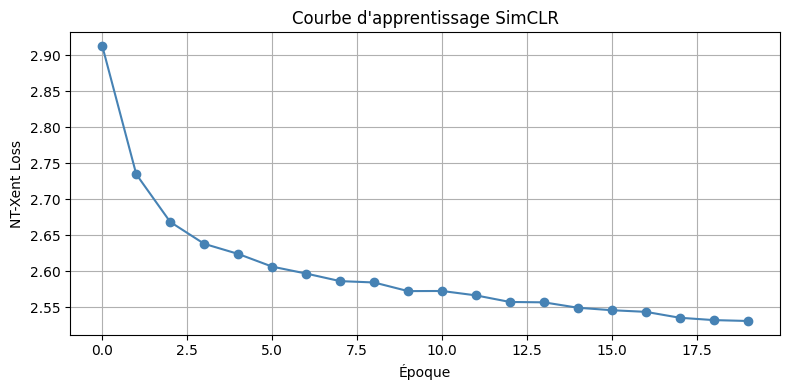

In [ ]:
BATCH_SIZE    = 32
EPOCHS_SIMCLR = 20

def make_pair(x):
    return augment(x), augment(x)

dataset = (
    tf.data.Dataset
    .from_tensor_slices(X_phot)
    .shuffle(len(X_phot))
    .map(make_pair, num_parallel_calls=tf.data.AUTOTUNE)
    .batch(BATCH_SIZE, drop_remainder=True)
    .prefetch(tf.data.AUTOTUNE)
)

losses_simclr = []
for epoch in range(EPOCHS_SIMCLR):
    batch_losses = []
    for x1, x2 in dataset:
        loss = train_step_simclr(x1, x2)
        batch_losses.append(float(loss))
    mean_loss = np.mean(batch_losses)
    losses_simclr.append(mean_loss)
    print(f"Epoch {epoch+1:2d}/{EPOCHS_SIMCLR}  NT-Xent loss = {mean_loss:.4f}")

plt.figure(figsize=(8, 4))
plt.plot(losses_simclr, 'o-', color='steelblue')
plt.xlabel("Époque"); plt.ylabel("NT-Xent Loss")
plt.title("Courbe d'apprentissage SimCLR")
plt.grid(True); plt.tight_layout(); plt.show()

## Fine-tuning pour la régression

L'encodeur pré-entraîné est gelé. On ajoute une tête de régression entraînée sur les images phot avec ZPHOT comme cible.

Model: "simclr_regressor"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 64, 64, 9)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder (Functional)            │ (None, 128)            │       111,488 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 119,809 (468.00 KB)

 Trainable params: 8,321 (32.50 KB)

 Non-trainable params: 111,488 (435.50 KB)

Epoch 1/30
352/352 ━━━━━━━━━━━━━━━━━━━━ 7s 12ms/step - loss: 5.4440 - mae: 1.0846 - val_loss: 0.8820 - val_mae: 0.7141
Epoch 2/30
352/352 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 1.1457 - mae: 0.7820 - val_loss: 0.8514 - val_mae: 0.7018
Epoch 3/30
352/352 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.8990 - mae: 0.7269 - val_loss: 0.8591 - val_mae: 0.6931
Epoch 4/30
352/352 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.8455 - mae: 0.7072 - val_loss: 0.8451 - val_mae: 0.6980
Epoch 5/30
352/352 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.8118 - mae: 0.6907 - val_loss: 0.8300 - val_mae: 0.6879
Epoch 6/30
352/352 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.8155 - mae: 0.6924 - val_loss: 0.8183 - val_mae: 0.6785
Epoch 7/30
352/352 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.7757 - mae: 0.6754 - val_loss: 0.8141 - val_mae: 0.6952
Epoch 8/30
352/352 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.7646 - mae: 0.6686 - val_loss: 0.8317 - val_mae: 0.6887
Epoch 9/30
352/352 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - l

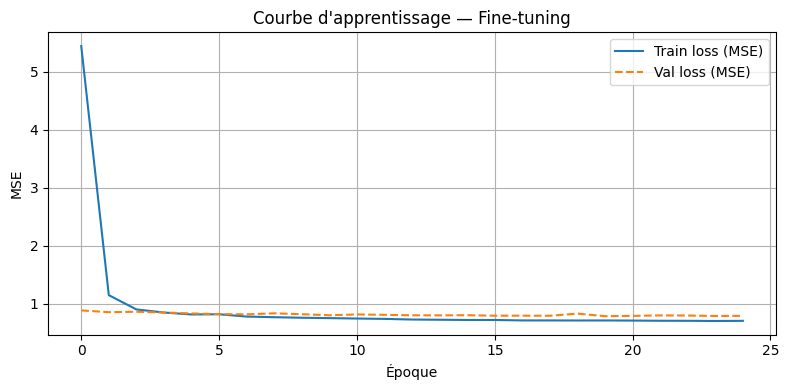

In [ ]:
encoder.trainable = False

inputs = layers.Input(shape=(64, 64, 9))
h      = encoder(inputs, training=False)
h      = layers.Dense(64, activation='relu')(h)
h      = layers.Dropout(0.3)(h)
out    = layers.Dense(1)(h)

regressor = models.Model(inputs, out, name='simclr_regressor')
regressor.compile(optimizer='adam', loss='mse', metrics=['mae'])
regressor.summary()

early_stop = EarlyStopping(monitor='val_loss', patience=5,
                            restore_best_weights=True, verbose=1)

history_ft = regressor.fit(
    X_phot, y_phot,
    epochs=30,
    batch_size=32,
    validation_split=0.1,
    callbacks=[early_stop],
    verbose=1
)

plt.figure(figsize=(8, 4))
plt.plot(history_ft.history['loss'],     label='Train loss (MSE)')
plt.plot(history_ft.history['val_loss'], label='Val loss (MSE)', linestyle='--')
plt.xlabel("Époque"); plt.ylabel("MSE")
plt.title("Courbe d'apprentissage — Fine-tuning")
plt.legend(); plt.grid(True); plt.tight_layout(); plt.show()

## Évaluation sur les données spec

── Métriques SimCLR sur données spec ───────────────────
  N objets   : 27
  MAE        : 1.1386
  Biais      : -0.1322
  NMAD       : 0.6192
  Outliers η : 0.852  (|Δz/(1+z)| > 0.15)


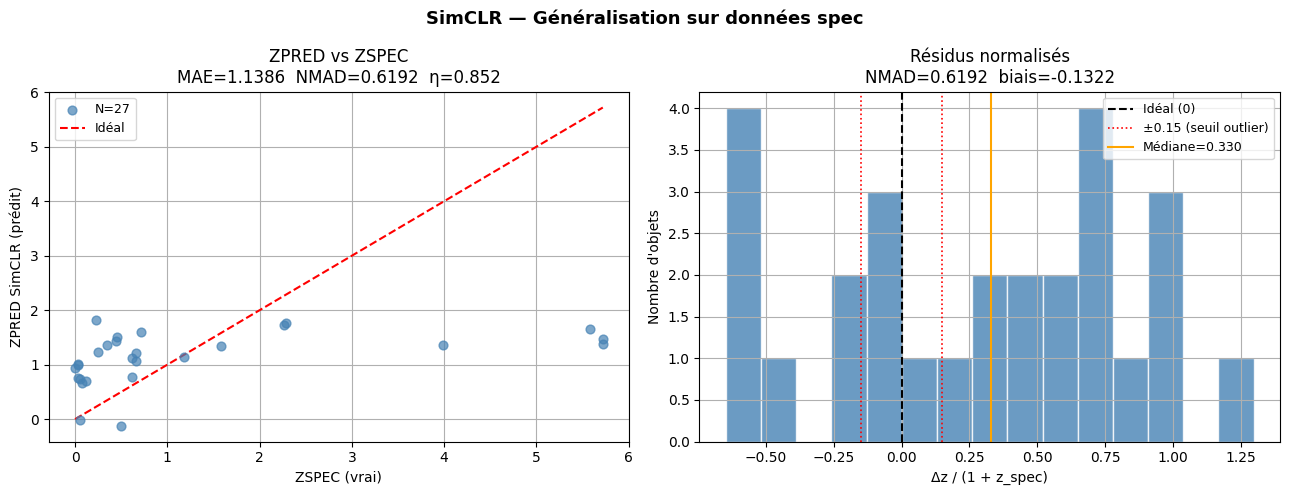

In [ ]:
z_pred = regressor.predict(X_spec, verbose=0).squeeze()
z_true = y_spec

dz_norm = (z_pred - z_true) / (1 + z_true)
mae     = np.mean(np.abs(z_pred - z_true))
bias    = np.mean(z_pred - z_true)
nmad    = 1.4826 * np.median(np.abs(dz_norm - np.median(dz_norm)))
eta     = np.mean(np.abs(dz_norm) > 0.15)

print("Métriques SimCLR sur données spec")
print(f"  N objets   : {len(z_true)}")
print(f"  MAE        : {mae:.4f}")
print(f"  Biais      : {bias:.4f}")
print(f"  NMAD       : {nmad:.4f}")
print(f"  Outliers η : {eta:.3f}  (|Δz/(1+z)| > 0.15)")

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("SimCLR — Généralisation sur données spec", fontsize=13, fontweight='bold')

ax = axes[0]
ax.scatter(z_true, z_pred, s=40, alpha=0.7, color='steelblue', zorder=3,
           label=f"N={len(z_true)}")
zmax = max(z_true.max(), z_pred.max())
ax.plot([0, zmax], [0, zmax], 'r--', lw=1.5, label='Idéal')
ax.set_xlabel("ZSPEC (vrai)"); ax.set_ylabel("ZPRED SimCLR (prédit)")
ax.set_title(f"ZPRED vs ZSPEC\nMAE={mae:.4f}  NMAD={nmad:.4f}  η={eta:.3f}")
ax.legend(fontsize=9); ax.grid(True)

ax = axes[1]
ax.hist(dz_norm, bins=15, color='steelblue', edgecolor='white', alpha=0.8)
ax.axvline(0,     color='black', lw=1.5, ls='--', label='Idéal (0)')
ax.axvline( 0.15, color='red',   lw=1.2, ls=':',  label='±0.15 (seuil outlier)')
ax.axvline(-0.15, color='red',   lw=1.2, ls=':')
ax.axvline(np.median(dz_norm), color='orange', lw=1.5,
           label=f"Médiane={np.median(dz_norm):.3f}")
ax.set_xlabel("Δz / (1 + z_spec)"); ax.set_ylabel("Nombre d'objets")
ax.set_title(f"Résidus normalisés\nNMAD={nmad:.4f}  biais={bias:.4f}")
ax.legend(fontsize=9); ax.grid(True)

plt.tight_layout()
plt.show()

# Visu t-SNE

Extraction des embeddings phot...
196/196 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step
Extraction des embeddings spec...
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 206ms/step
t-SNE sur 2027 points...


/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


t-SNE terminé.


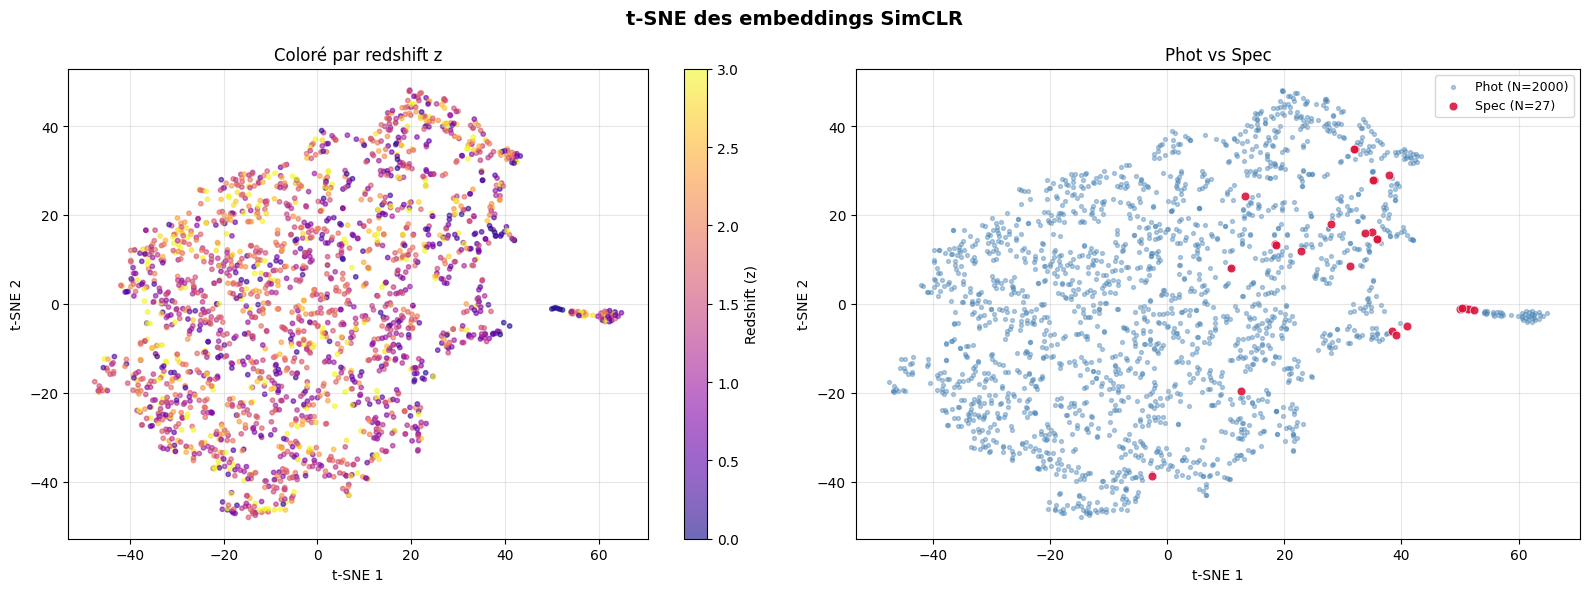

Figure sauvegardée : tsne_simclr.png


In [ ]:
# Extraction des embeddings

print("Extraction des embeddings phot")
emb_phot = encoder.predict(X_phot, batch_size=64, verbose=1)  # (N_phot, 128)

print("Extraction des embeddings spec")
emb_spec = encoder.predict(X_spec, batch_size=64, verbose=1)  # (N_spec, 128)

# Sous-échantillonnage phot pour lisibilité (max 2000)

N_sample = min(2000, len(emb_phot))
idx = np.random.choice(len(emb_phot), N_sample, replace=False)
emb_phot_s = emb_phot[idx]
y_phot_s   = y_phot[idx]

# t-SNE sur phot + spec concaténés

all_emb    = np.concatenate([emb_phot_s, emb_spec], axis=0)
all_z      = np.concatenate([y_phot_s,   y_spec],   axis=0)
all_source = np.array(['phot'] * len(emb_phot_s) + ['spec'] * len(emb_spec))

print(f"t-SNE sur {len(all_emb)} points")
tsne = TSNE(n_components=2, perplexity=30, learning_rate='auto',
            init='pca', n_iter=1000, random_state=42)
emb_2d = tsne.fit_transform(all_emb)
print("t-SNE terminé.")

# Figure

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("t-SNE des embeddings SimCLR", fontsize=14, fontweight='bold')

# Plot 1 : coloré par redshift

ax = axes[0]
sc = ax.scatter(emb_2d[:, 0], emb_2d[:, 1],
                c=all_z, cmap='plasma', s=10, alpha=0.6, vmin=0, vmax=3)
plt.colorbar(sc, ax=ax, label='Redshift (z)')
ax.set_title("Coloré par redshift z")
ax.set_xlabel("t-SNE 1"); ax.set_ylabel("t-SNE 2")
ax.grid(True, alpha=0.3)

# Plot 2 : coloré par source (phot vs spec)

ax = axes[1]
mask_ph = all_source == 'phot'
mask_sp = all_source == 'spec'
ax.scatter(emb_2d[mask_ph, 0], emb_2d[mask_ph, 1],
           c='steelblue', s=8,  alpha=0.4, label=f'Phot (N={mask_ph.sum()})')
ax.scatter(emb_2d[mask_sp, 0], emb_2d[mask_sp, 1],
           c='crimson',   s=40, alpha=0.9, label=f'Spec (N={mask_sp.sum()})',
           edgecolors='white', linewidths=0.5, zorder=3)
ax.set_title("Phot vs Spec")
ax.set_xlabel("t-SNE 1"); ax.set_ylabel("t-SNE 2")
ax.legend(fontsize=9); ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("tsne_simclr.png", dpi=150, bbox_inches='tight')
plt.show()
print("Figure sauvegardée : tsne_simclr.png")

# Fine-tuning sans surapprentissage


PHASE 1 — Encodeur gelé, warm-up de la tête
Epoch 1/20
352/352 ━━━━━━━━━━━━━━━━━━━━ 10s 15ms/step - loss: 1.1652 - mae: 0.8099 - val_loss: 0.9418 - val_mae: 0.7018 - learning_rate: 0.0010
Epoch 2/20
352/352 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.8975 - mae: 0.7214 - val_loss: 0.9258 - val_mae: 0.6964 - learning_rate: 0.0010
Epoch 3/20
352/352 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.8467 - mae: 0.7005 - val_loss: 0.8680 - val_mae: 0.6809 - learning_rate: 0.0010
Epoch 4/20
352/352 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.8123 - mae: 0.6826 - val_loss: 0.9100 - val_mae: 0.6954 - learning_rate: 0.0010
Epoch 5/20
352/352 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 0.8032 - mae: 0.6798 - val_loss: 0.8680 - val_mae: 0.6828 - learning_rate: 0.0010
Epoch 6/20
352/352 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.7856 - mae: 0.6715 - val_loss: 0.8477 - val_mae: 0.6835 - learning_rate: 0.0010
Epoch 7/20
352/352 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.7687 - mae: 0.6646 - val_loss: 0.8449 - 

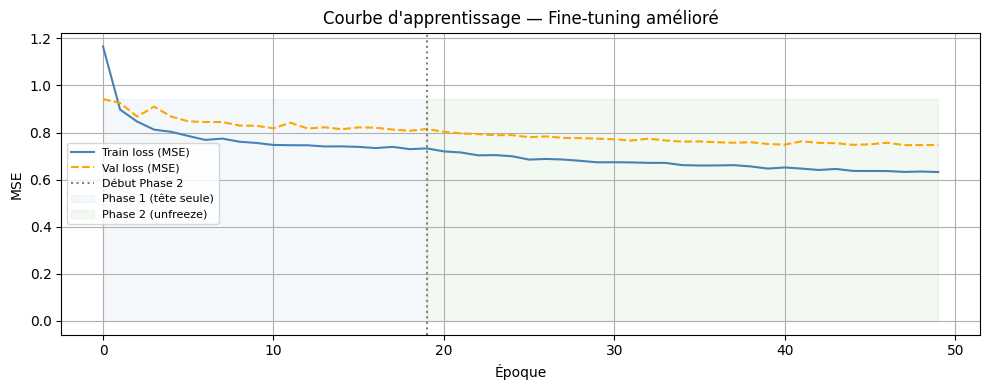

In [ ]:
L2_REG = 1e-4

# Reconstruction encodeur (repartir du pré-entraîné)
encoder.trainable = False   # Phase 1 : tout gelé

inputs = layers.Input(shape=(64, 64, 9))
h = encoder(inputs, training=False)

# Tête améliorée

h = layers.BatchNormalization()(h)
h = layers.Dense(128, activation='relu',
                 kernel_regularizer=regularizers.l2(L2_REG))(h)
h = layers.Dropout(0.4)(h)
h = layers.Dense(64, activation='relu',
                 kernel_regularizer=regularizers.l2(L2_REG))(h)
h = layers.Dropout(0.3)(h)
out = layers.Dense(1)(h)

regressor2 = models.Model(inputs, out, name='simclr_regressor_v2')

# Phase 1 : entraîner la tête seule

print("=" * 55)
print("PHASE 1 — Encodeur gelé, warm-up de la tête")
print("=" * 55)

regressor2.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='mse', metrics=['mae']
)

es1 = EarlyStopping(monitor='val_loss', patience=5,
                    restore_best_weights=True, verbose=1)
rlr1 = ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                          patience=3, verbose=1, min_lr=1e-6)

hist1 = regressor2.fit(
    X_phot, y_phot,
    epochs=20, batch_size=32,
    validation_split=0.1,
    callbacks=[es1, rlr1], verbose=1
)

# Phase 2 : dégeler les 2 dernières couches de l'encodeur

print("\n" + "=" * 55)
print("PHASE 2 — Unfreeze partiel de l'encodeur (fine)")
print("=" * 55)

# Dégel des 2 dernières couches conv/dense de l'encodeur

for layer in encoder.layers[:-4]:
    layer.trainable = False
for layer in encoder.layers[-4:]:
    layer.trainable = True

trainable_params = np.sum([np.prod(v.shape) for v in regressor2.trainable_variables])
print(f"Paramètres entraînables phase 2 : {trainable_params:,}")

regressor2.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),   # LR 10x plus faible
    loss='mse', metrics=['mae']
)

es2  = EarlyStopping(monitor='val_loss', patience=7,
                     restore_best_weights=True, verbose=1)
rlr2 = ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                          patience=3, verbose=1, min_lr=1e-7)

hist2 = regressor2.fit(
    X_phot, y_phot,
    epochs=30, batch_size=32,
    validation_split=0.1,
    callbacks=[es2, rlr2], verbose=1
)

# Courbes combinées

train_loss = hist1.history['loss']     + hist2.history['loss']
val_loss   = hist1.history['val_loss'] + hist2.history['val_loss']
ep1_end    = len(hist1.history['loss'])

plt.figure(figsize=(10, 4))
plt.plot(train_loss, label='Train loss (MSE)', color='steelblue')
plt.plot(val_loss,   label='Val loss (MSE)',   color='orange', linestyle='--')
plt.axvline(ep1_end - 1, color='gray', ls=':', lw=1.5, label='Début Phase 2')
plt.fill_between(range(ep1_end), 0, max(val_loss),
                 alpha=0.05, color='steelblue', label='Phase 1 (tête seule)')
plt.fill_between(range(ep1_end - 1, len(train_loss)), 0, max(val_loss),
                 alpha=0.05, color='green', label='Phase 2 (unfreeze)')
plt.xlabel("Époque"); plt.ylabel("MSE")
plt.title("Courbe d'apprentissage — Fine-tuning amélioré")
plt.legend(fontsize=8); plt.grid(True); plt.tight_layout()
plt.savefig("finetuning_courbe_apprentissage.png", dpi=150, bbox_inches='tight')
plt.show()

# Evaluation du modèle ajusté

── Métriques SimCLR v2 sur données spec ─────────────────
  MAE   : 1.0707   (avant : 1.1386)
  Biais : -0.3737   (avant : -0.1322)
  NMAD  : 0.6590   (avant : 0.6192)
  η     : 0.778    (avant : 0.852)


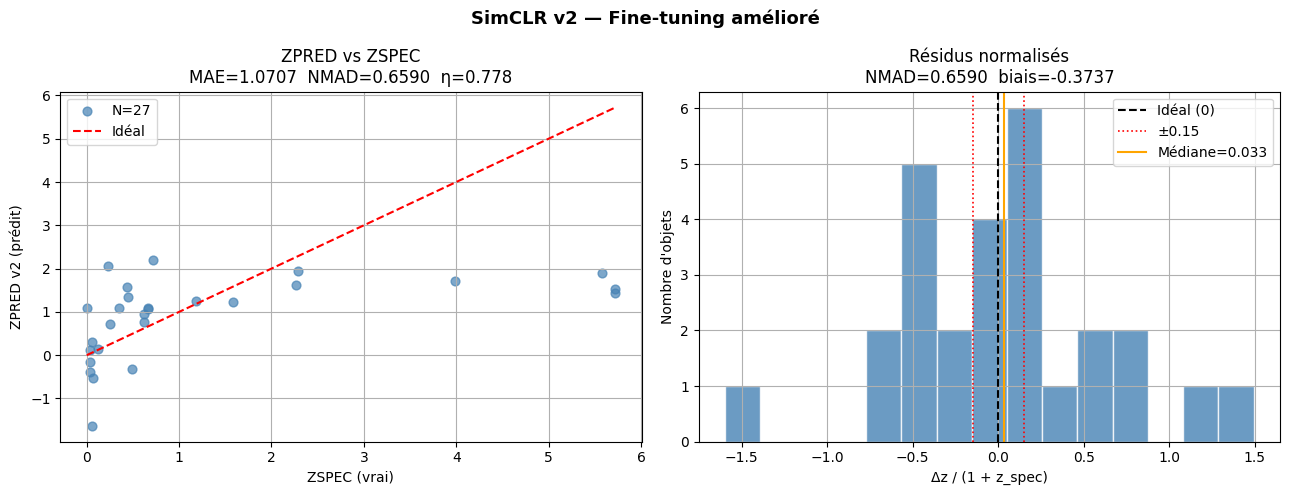

In [ ]:
z_pred2 = regressor2.predict(X_spec, verbose=0).squeeze()
z_true  = y_spec

dz_norm2 = (z_pred2 - z_true) / (1 + z_true)
mae2     = np.mean(np.abs(z_pred2 - z_true))
bias2    = np.mean(z_pred2 - z_true)
nmad2    = 1.4826 * np.median(np.abs(dz_norm2 - np.median(dz_norm2)))
eta2     = np.mean(np.abs(dz_norm2) > 0.15)

print("Métriques SimCLR v2 sur données spec")
print(f"  MAE   : {mae2:.4f}   (avant : {mae:.4f})")
print(f"  Biais : {bias2:.4f}   (avant : {bias:.4f})")
print(f"  NMAD  : {nmad2:.4f}   (avant : {nmad:.4f})")
print(f"  η     : {eta2:.3f}    (avant : {eta:.3f})")

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("SimCLR v2 — Fine-tuning amélioré", fontsize=13, fontweight='bold')

ax = axes[0]
ax.scatter(z_true, z_pred2, s=40, alpha=0.7, color='steelblue', label=f"N={len(z_true)}")
zmax = max(z_true.max(), z_pred2.max())
ax.plot([0, zmax], [0, zmax], 'r--', lw=1.5, label='Idéal')
ax.set_xlabel("ZSPEC (vrai)"); ax.set_ylabel("ZPRED v2 (prédit)")
ax.set_title(f"ZPRED vs ZSPEC\nMAE={mae2:.4f}  NMAD={nmad2:.4f}  η={eta2:.3f}")
ax.legend(); ax.grid(True)

ax = axes[1]
ax.hist(dz_norm2, bins=15, color='steelblue', edgecolor='white', alpha=0.8)
ax.axvline(0,     color='black', lw=1.5, ls='--', label='Idéal (0)')
ax.axvline( 0.15, color='red',   lw=1.2, ls=':', label='±0.15')
ax.axvline(-0.15, color='red',   lw=1.2, ls=':')
ax.axvline(np.median(dz_norm2), color='orange', lw=1.5,
           label=f"Médiane={np.median(dz_norm2):.3f}")
ax.set_xlabel("Δz / (1 + z_spec)"); ax.set_ylabel("Nombre d'objets")
ax.set_title(f"Résidus normalisés\nNMAD={nmad2:.4f}  biais={bias2:.4f}")
ax.legend(); ax.grid(True)

plt.tight_layout()
plt.savefig("simclr_v2_evaluation.png", dpi=150, bbox_inches='tight')
plt.show()

# Visu t-SNE multivariables

Extraction des embeddings phot...
196/196 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step
Extraction des embeddings spec...
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step

Champs disponibles dans phot_info : ('ID', 'RA', 'DEC', 'TRACT', 'PATCH', 'MASK', 'FLAG_FIELD', 'EB_V', 'CLASS_STAR_HSC_I', 'u', 'uS', 'g', 'r', 'i', 'z', 'y', 'J', 'H', 'Ks', 'u_err', 'uS_err', 'g_err', 'r_err', 'i_err', 'z_err', 'y_err', 'J_err', 'H_err', 'Ks_err', 'ZPHOT', 'OBJ_TYPE', 'COMPACT', 'STAR_FORMING', 'ST_TRAIL', 'CLEAN', 'EBV', 'LABEL')
Variables disponibles pour coloration : ['RA', 'DEC', 'ZPHOT']

t-SNE sur 2000 points phot...


/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


t-SNE terminé.


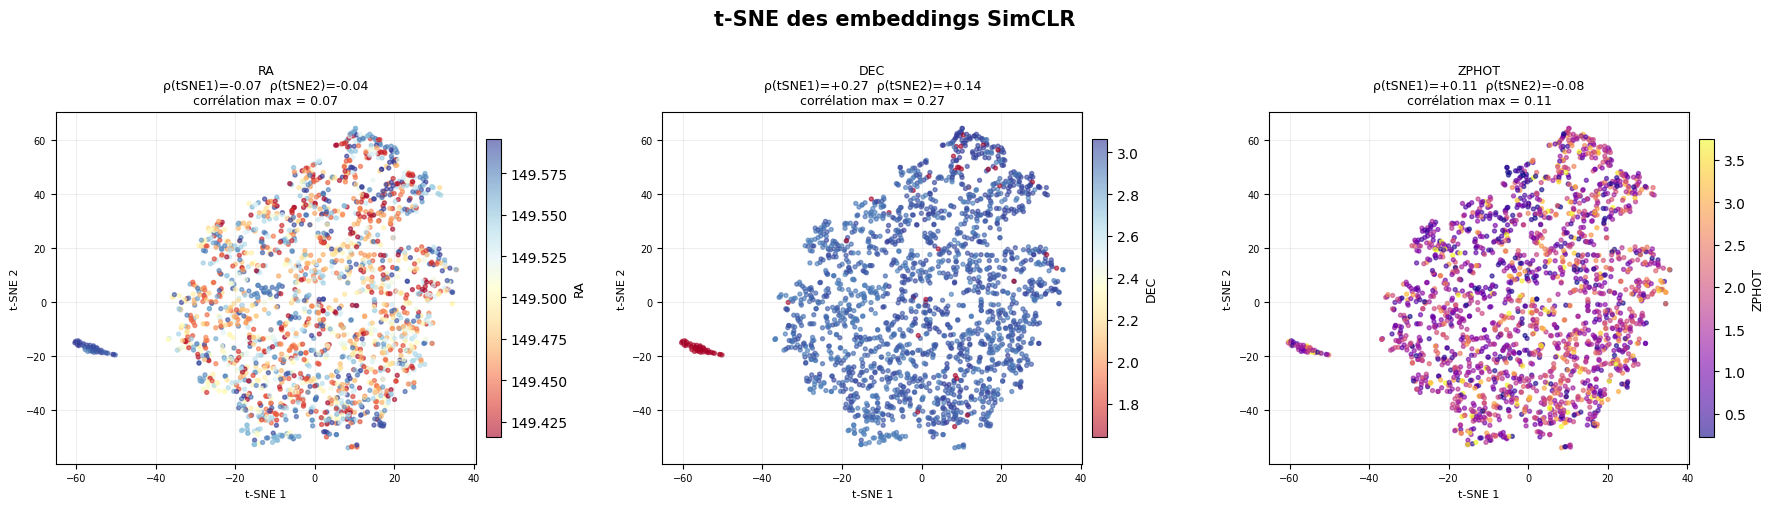


 Interprétation
  RA              → ρ_max=0.07  neutre
  DEC             → ρ_max=0.27  neutre
  ZPHOT           → ρ_max=0.11  ρ=0.11


In [ ]:
# Extraction des embeddings

print("Extraction des embeddings phot")
emb_phot = encoder.predict(X_phot, batch_size=64, verbose=1)

print("Extraction des embeddings spec")
emb_spec = encoder.predict(X_spec, batch_size=64, verbose=1)

# Sous-échantillonnage phot pour lisibilité

N_sample = min(2000, len(emb_phot))
idx = np.random.choice(len(emb_phot), N_sample, replace=False)
emb_phot_s = emb_phot[idx]
info_s     = phot_info[idx]

# Récupération des variables pour la colorisation

def safe_get(arr, field):
    """Retourne le champ si disponible, sinon None."""
    try:
        v = arr[field].astype(np.float32)
        return v if np.any(np.isfinite(v)) else None
    except (ValueError, KeyError):
        return None

available = phot_info.dtype.names
print(f"\nChamps disponibles dans phot_info : {available}")

variables = {}
for field in ['RA', 'DEC', 'ZPHOT', 'MAG_AUTO', 'FLUX_RADIUS',
              'MU_MAX', 'ELLIPTICITY', 'CLASS_STAR']:
    v = safe_get(info_s, field)
    if v is not None:
        variables[field] = v

if 'ZPHOT' not in variables:
    variables['ZPHOT'] = y_phot[idx]

print(f"Variables disponibles pour coloration : {list(variables.keys())}")

# t-SNE

print(f"\nt-SNE sur {len(emb_phot_s)} points phot...")
tsne = TSNE(n_components=2, perplexity=30, learning_rate='auto',
            init='pca', n_iter=1000, random_state=42)
emb_2d = tsne.fit_transform(emb_phot_s)
print("t-SNE terminé.")

# Figure multi-variables

n_vars = len(variables)
ncols  = 3
nrows  = (n_vars + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(6 * ncols, 5 * nrows))
fig.suptitle("t-SNE des embeddings SimCLR",
             fontsize=15, fontweight='bold', y=1.01)
axes = np.array(axes).flatten()

cmaps = {
    'RA':          'RdYlBu',
    'DEC':         'RdYlBu',
    'ZPHOT':       'plasma',
    'MAG_AUTO':    'viridis_r',
    'FLUX_RADIUS': 'cividis',
    'MU_MAX':      'magma',
    'ELLIPTICITY': 'coolwarm',
    'CLASS_STAR':  'bwr',
}

for ax, (name, values) in zip(axes, variables.items()):
    vmin, vmax = np.nanpercentile(values, [2, 98])
    sc = ax.scatter(emb_2d[:, 0], emb_2d[:, 1],
                    c=values, cmap=cmaps.get(name, 'viridis'),
                    s=8, alpha=0.6, vmin=vmin, vmax=vmax)
    cb = plt.colorbar(sc, ax=ax, pad=0.02, shrink=0.85)
    cb.set_label(name, fontsize=9)

    finite = np.isfinite(values)
    r1, _ = spearmanr(emb_2d[finite, 0], values[finite])
    r2, _ = spearmanr(emb_2d[finite, 1], values[finite])
    rmax  = max(abs(r1), abs(r2))

    ax.set_title(f"{name}\nρ(tSNE1)={r1:+.2f}  ρ(tSNE2)={r2:+.2f}\ncorrélation max = {rmax:.2f}",
                 fontsize=9)
    ax.set_xlabel("t-SNE 1", fontsize=8)
    ax.set_ylabel("t-SNE 2", fontsize=8)
    ax.tick_params(labelsize=7)
    ax.grid(True, alpha=0.2)

for ax in axes[n_vars:]:
    ax.set_visible(False)

plt.tight_layout()
plt.savefig("tsne_multivariable.png", dpi=150, bbox_inches='tight')
plt.show()

# Résumé interprétation

print("\n Interprétation")

for name, values in variables.items():
    finite = np.isfinite(values)
    r1, _ = spearmanr(emb_2d[finite, 0], values[finite])
    r2, _ = spearmanr(emb_2d[finite, 1], values[finite])
    rmax  = max(abs(r1), abs(r2))
    interp = "bien capturée" if name == 'ZPHOT' and rmax > 0.3 else \
             "biais position" if name in ('RA', 'DEC') and rmax > 0.3 else \
             "neutre" if name in ('RA', 'DEC') and rmax <= 0.3 else \
             f"ρ={rmax:.2f}"
    print(f"  {name:15s} → ρ_max={rmax:.2f}  {interp}")

#Téléchargement des graphiques

In [ ]:
figures = [
    "finetuning_courbe_apprentissage.png",
    "simclr_v2_evaluation.png",
    "tsne_multivariable.png",
    "tsne_simclr.png",
]

for f in figures:
    files.download(f)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>